In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [5]:
credit_data = pd.read_csv('creditcard.csv',nrows = 40000)
credit_data

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,40049,-1.051131,0.606656,0.441297,0.590587,-0.118730,1.010767,2.282192,-0.751310,0.141134,...,-0.168207,0.495169,-0.066540,-0.904026,-0.149187,-0.302797,-0.188726,-0.248812,280.18,0
39996,40049,1.188332,0.360587,-0.024267,1.179898,-0.095200,-0.975171,0.403633,-0.160097,-0.460291,...,0.063470,0.115945,-0.129453,0.527456,0.748484,-0.308659,-0.022350,0.003130,15.33,0
39997,40050,1.038810,-2.090833,0.852849,-0.847290,-2.112321,0.291188,-1.321491,0.007713,-0.771225,...,-0.059743,0.138289,-0.341212,-0.045303,0.516037,0.016258,0.051843,0.061811,236.19,0
39998,40052,1.211027,0.614544,-0.459212,0.900736,0.135725,-1.175774,0.337603,-0.198540,-0.188104,...,-0.105254,-0.214124,-0.013156,0.287419,0.453268,0.378507,-0.013994,0.042698,0.76,0


In [10]:
StandardScaler().fit_transform(credit_data.loc[:,credit_data.columns!='Class'])
scaled_data = scaler[0:40000]
df = pd.DataFrame(data=scaled_data)

In [12]:
X = credit_data.drop(columns=['Class'])
y = credit_data['Class']

Step 3: Model Making

In [16]:
outlier_fraction = len(credit_data[credit_data['Class']==1])/float(len(credit_data[credit_data['Class']==0]))

In [21]:
model =  IsolationForest(n_estimators=100, contamination=outlier_fraction, random_state=42)
model.fit(df)

IsolationForest(contamination=0.0026067776218167233, random_state=42)

Step 4: Model Evaluation

In [22]:
scores_prediction = model.decision_function(df)

y_pred = model.predict(df)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

print("Accuracy in finding anomaly:",accuracy_score(y,y_pred))

Accuracy in finding anomaly: 0.997175


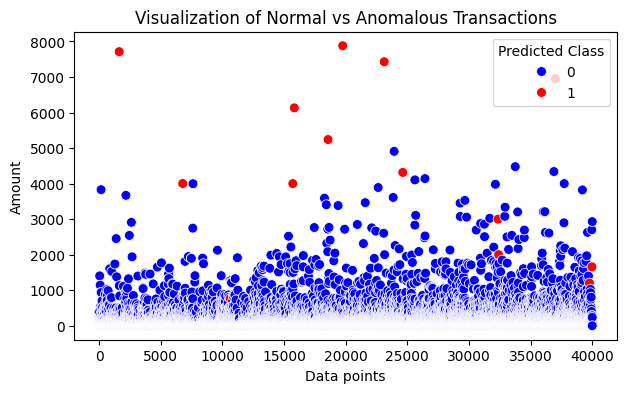

In [23]:
y_feature = credit_data['Amount']
credit_data['predicted_class'] = y_pred

plt.figure(figsize=(7, 4))
sns.scatterplot(x=credit_data.index, y=y_feature, hue=credit_data['predicted_class'], palette={0: 'blue', 1: 'red'}, s=50)
plt.title('Visualization of Normal vs Anomalous Transactions')
plt.xlabel('Data points')
plt.ylabel(y_feature.name)
plt.legend(title='Predicted Class', loc='best')
plt.show()